In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kriteethapa/restaurant-sales/restaurant_sales.csv


# FINAL YEAR PROJECT 2026

## Data Loading

The restaurant sales dataset is loaded using the Pandas library.  
This dataset contains daily sales information which will be used to train the forecasting model.

The first few rows are displayed to confirm that the dataset has been imported correctly.

In [2]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/kriteethapa/restaurant-sales/restaurant_sales.csv")

df.head()

,date,sales,day_of_week,is_weekend
0,1/1/2024,1249,Monday,0
1,1/2/2024,1186,Tuesday,0
2,1/3/2024,1264,Wednesday,0
3,1/4/2024,1352,Thursday,0
4,1/5/2024,1176,Friday,0


## Checking  Structure
Data Inspection
The structure of the dataset is examined using df.info() and df.describe().

This step helps understand:
- the number of observations
- data types of each column
- statistical properties of the sales variable

Understanding the dataset structure is important before performing preprocessing and modelling.

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         366 non-null    object
 1   sales        366 non-null    int64 
 2   day_of_week  366 non-null    object
 3   is_weekend   366 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 11.6+ KB


,sales,is_weekend
count,366.000000,366.000000
mean,1342.464481,0.284153
std,248.295234,0.451627
min,875.000000,0.000000
25%,1157.500000,0.000000
50%,1240.500000,0.000000
75%,1582.000000,1.000000
max,2085.000000,1.000000


## Date Conversion

The date column is converted into datetime format and sorted chronologically.

This is required for time-series forecasting because the model must learn patterns from past observations to predict future sales.

In [4]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

## Duplicate Check

Duplicate records are checked using df.duplicated().

Removing duplicates ensures that each observation is unique and prevents biased model training.

In [5]:
df.duplicated().sum()

np.int64(0)

## Missing Values

The dataset is checked for missing values using df.isnull().

Handling missing data is necessary because machine learning models require complete numerical input.

In [6]:
df.isnull().sum()

date           0
sales          0
day_of_week    0
is_weekend     0
dtype: int64

In [7]:
df.describe()

,date,sales,is_weekend
count,366,366.000000,366.000000
mean,2024-07-01 12:00:00.000000256,1342.464481,0.284153
min,2024-01-01 00:00:00,875.000000,0.000000
25%,2024-04-01 06:00:00,1157.500000,0.000000
50%,2024-07-01 12:00:00,1240.500000,0.000000
75%,2024-09-30 18:00:00,1582.000000,1.000000
max,2024-12-31 00:00:00,2085.000000,1.000000
std,NaN,248.295234,0.451627


### Checking aggregation


In [8]:
print("Unique dates:", df['date'].nunique())
print("Total rows:", len(df))

Unique dates: 366
Total rows: 366


## Time Feature Engineering

Time-based features are extracted from the date column.

These include:
- day_of_week
- month
- weekend indicator

These variables help capture temporal patterns in restaurant demand.

In [9]:
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

df.head(15)

,date,sales,day_of_week,is_weekend,month
0,2024-01-01,1249,0,0,1
1,2024-01-02,1186,1,0,1
2,2024-01-03,1264,2,0,1
3,2024-01-04,1352,3,0,1
4,2024-01-05,1176,4,0,1
5,2024-01-06,1676,5,1,1
6,2024-01-07,1857,6,1,1
7,2024-01-08,1276,0,0,1
8,2024-01-09,1153,1,0,1
9,2024-01-10,1254,2,0,1


## Lag Features

Lag variables represent past sales values.

Examples:
- lag_1 → sales from the previous day
- lag_7 → sales from the previous week
- lag_14 → sales from two weeks earlier

Lag features allow the model to learn historical demand patterns.

In [10]:
df['lag_1'] = df['sales'].shift(1)
df['lag_7'] = df['sales'].shift(7)
df['lag_14'] = df['sales'].shift(14)

df.head(20)

,date,sales,day_of_week,is_weekend,month,lag_1,lag_7,lag_14
0,2024-01-01,1249,0,0,1,NaN,NaN,NaN
1,2024-01-02,1186,1,0,1,1249.0,NaN,NaN
2,2024-01-03,1264,2,0,1,1186.0,NaN,NaN
3,2024-01-04,1352,3,0,1,1264.0,NaN,NaN
4,2024-01-05,1176,4,0,1,1352.0,NaN,NaN
5,2024-01-06,1676,5,1,1,1176.0,NaN,NaN
6,2024-01-07,1857,6,1,1,1676.0,NaN,NaN
7,2024-01-08,1276,0,0,1,1857.0,1249.0,NaN
8,2024-01-09,1153,1,0,1,1276.0,1186.0,NaN
9,2024-01-10,1254,2,0,1,1153.0,1264.0,NaN


## Rolling Average Feature

A 7-day rolling average of sales is created.

This feature helps capture the overall weekly trend and reduces noise in daily sales data.

In [11]:
df['rolling_7'] = df['sales'].rolling(7).mean()

df.head(10)

,date,sales,day_of_week,is_weekend,month,lag_1,lag_7,lag_14,rolling_7
0,2024-01-01,1249,0,0,1,NaN,NaN,NaN,NaN
1,2024-01-02,1186,1,0,1,1249.0,NaN,NaN,NaN
2,2024-01-03,1264,2,0,1,1186.0,NaN,NaN,NaN
3,2024-01-04,1352,3,0,1,1264.0,NaN,NaN,NaN
4,2024-01-05,1176,4,0,1,1352.0,NaN,NaN,NaN
5,2024-01-06,1676,5,1,1,1176.0,NaN,NaN,NaN
6,2024-01-07,1857,6,1,1,1676.0,NaN,NaN,1394.285714
7,2024-01-08,1276,0,0,1,1857.0,1249.0,NaN,1398.142857
8,2024-01-09,1153,1,0,1,1276.0,1186.0,NaN,1393.428571
9,2024-01-10,1254,2,0,1,1153.0,1264.0,NaN,1392.000000


In [12]:
df[['sales','lag_1','lag_7','lag_14','rolling_7']].head(15)

,sales,lag_1,lag_7,lag_14,rolling_7
0,1249,NaN,NaN,NaN,NaN
1,1186,1249.0,NaN,NaN,NaN
2,1264,1186.0,NaN,NaN,NaN
3,1352,1264.0,NaN,NaN,NaN
4,1176,1352.0,NaN,NaN,NaN
5,1676,1176.0,NaN,NaN,NaN
6,1857,1676.0,NaN,NaN,1394.285714
7,1276,1857.0,1249.0,NaN,1398.142857
8,1153,1276.0,1186.0,NaN,1393.428571
9,1254,1153.0,1264.0,NaN,1392.000000


## Handling Missing Values from Feature Engineering

Lag and rolling features create missing values at the beginning of the dataset.

These rows are removed to ensure the dataset is suitable for machine learning models.

In [13]:
df = df.dropna()

df.head()

,date,sales,day_of_week,is_weekend,month,lag_1,lag_7,lag_14,rolling_7
14,2024-01-15,1027,0,0,1,1508.0,1276.0,1249.0,1281.714286
15,2024-01-16,1143,1,0,1,1027.0,1153.0,1186.0,1280.285714
16,2024-01-17,1098,2,0,1,1143.0,1254.0,1264.0,1258.000000
17,2024-01-18,1231,3,0,1,1098.0,1153.0,1352.0,1269.142857
18,2024-01-19,1109,4,0,1,1231.0,1153.0,1176.0,1262.857143


## Exploratory Data Analysis (EDA)

### Sales trend over time

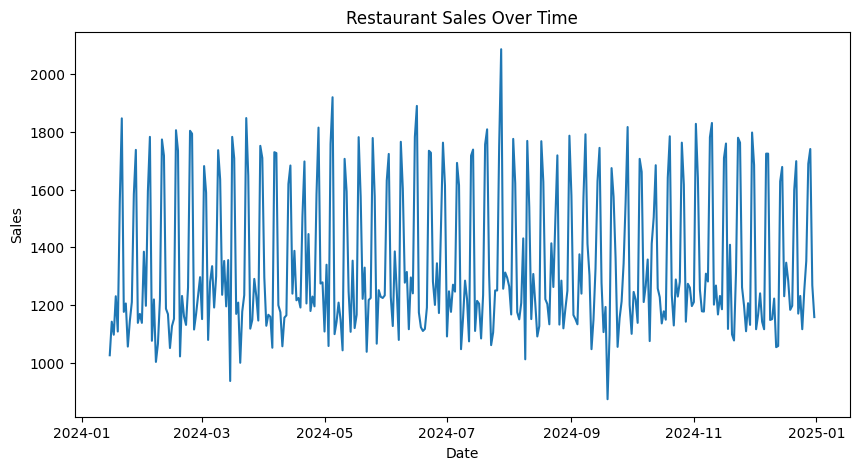

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['date'], df['sales'])
plt.title("Restaurant Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

### Sales by weekday

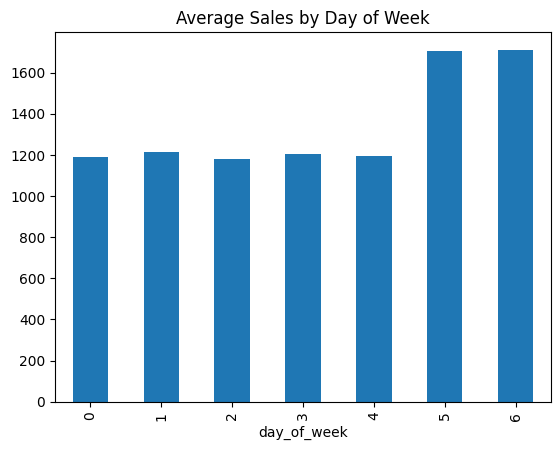

In [15]:
df.groupby('day_of_week')['sales'].mean().plot(kind='bar')
plt.title("Average Sales by Day of Week")
plt.show()

## Feature and Target Definition

The input variables (features) are separated from the target variable.

Features include temporal and lag-based variables that describe historical demand patterns.

The target variable is daily sales, which the model aims to predict.

In [16]:
features = ['day_of_week','month','is_weekend','lag_1','lag_7','lag_14','rolling_7']
X = df[features]

y = df['sales']

## Chronological Train-Test Split

The dataset is divided into training and testing sets using chronological order.

This prevents data leakage by ensuring the model is trained on past data and evaluated on future observations.

In [17]:
split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

## Linear Regression Model

A Linear Regression model is trained as a baseline forecasting model.

The model learns relationships between historical sales features
(day_of_week, lag variables, rolling averages) and future sales values.

In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

In [19]:
y_pred_lr = model.predict(X_test)

## Model Evaluation

The forecasting model is evaluated using Mean Absolute Error (MAE)
and Root Mean Squared Error (RMSE).

These metrics measure how closely predicted sales match actual sales values.
Lower values indicate better model performance.

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_lr = mean_absolute_error(y_test,y_pred_lr)
rmse_lr = mean_squared_error(y_test,y_pred_lr)**0.5

print("Linear Regression MAE:",mae_lr)
print("Linear Regression RMSE:",rmse_lr)

Linear Regression MAE: 56.48824898618139
Linear Regression RMSE: 69.36499219663365


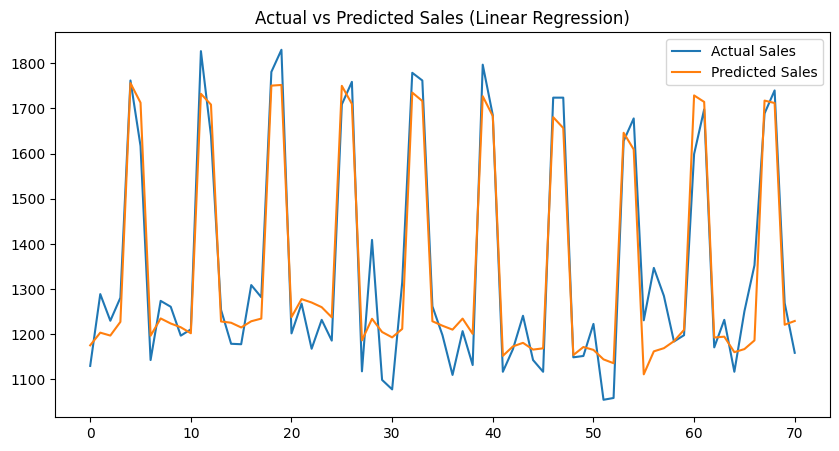

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test.values, label="Actual Sales")
plt.plot(y_pred_lr, label="Predicted Sales")

plt.legend()
plt.title("Actual vs Predicted Sales (Linear Regression)")

plt.show()

## Random Forest Model

A Random Forest regression model is trained to capture non-linear
relationships in the data.

Random Forest combines multiple decision trees to improve prediction
accuracy and robustness compared to simple linear models.

In [22]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)

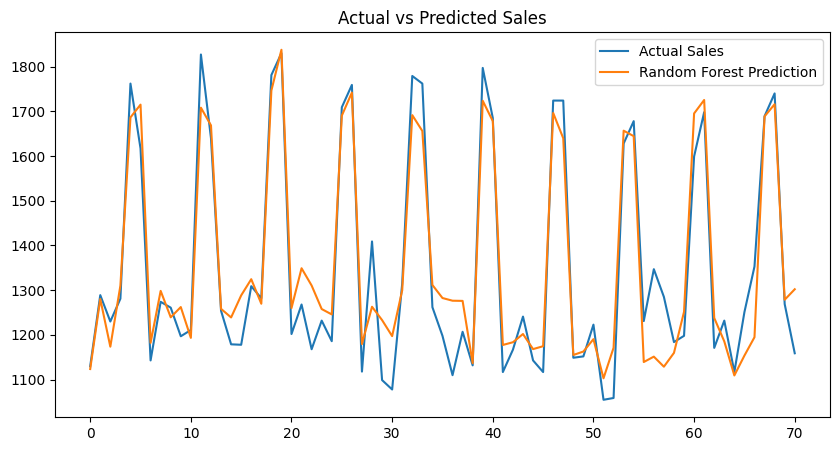

In [23]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values,label="Actual Sales")
plt.plot(y_pred_rf,label="Random Forest Prediction")

plt.legend()

plt.title("Actual vs Predicted Sales")

plt.show()

## Model Comparison

Two forecasting models were compared:

1. Linear Regression
2. Random Forest

Performance metrics show that Random Forest produced lower error values,
indicating improved forecasting accuracy.

In [24]:
mae_rf = mean_absolute_error(y_test,y_pred_rf)
rmse_rf = mean_squared_error(y_test,y_pred_rf)**0.5

print("Linear Regression MAE:",mae_lr)
print("Random Forest MAE:",mae_rf)

print("Linear Regression RMSE:",rmse_lr)
print("Random Forest RMSE:",rmse_rf)

Linear Regression MAE: 56.48824898618139
Random Forest MAE: 58.36408450704224
Linear Regression RMSE: 69.36499219663365
Random Forest RMSE: 75.0937694476656


## Feature Importance Analysis

Feature importance analysis was performed using the Random Forest model.

The results indicate which variables have the strongest influence
on sales predictions. Lag-based features, particularly lag_14,
were the most important predictors, suggesting strong weekly
seasonality in restaurant demand.

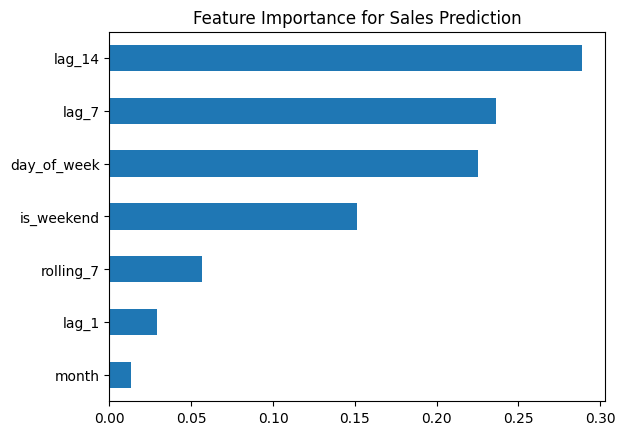

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(rf.feature_importances_, index=features)

importance.sort_values().plot(kind='barh')

plt.title("Feature Importance for Sales Prediction")

plt.show()

## Forecast Visualization

Actual and predicted sales values are plotted to visually assess forecasting performance.

This allows observation of how well the model captures sales trends.

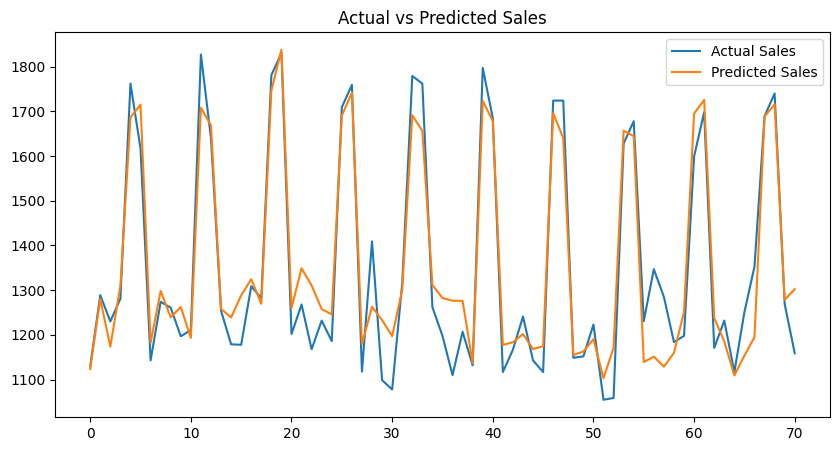

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values,label="Actual Sales")
plt.plot(y_pred_rf,label="Predicted Sales")
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()